In [ ]:
from hydra import compose, initialize

# from utils.tools import load_models
from synthetic_anomalies import (
    add_event_group,
    reverse_event,
    display_anomaly,
    model,
    add_seasonal_cycle_increase,
    add_trend_increase,
)

import matplotlib.pyplot as plt
import sys

sys.path.append("../")
from forecasting_analysis.utils.data_parsing_tools import load_data_bases

In [2]:
%load_ext autoreload
%autoreload 2

# Early pipeline for anomaly detection

Here we rely on the residual patterns of residual models to detect anomalies as fast as possible.

This is unpublished early work. Notably, depending on the anomaly, this approach works perfect or not so perfect. Here a proper model selection as well as method tuning is likely to help.






In [12]:
with initialize(version_base=None, config_path="conf"):
    cfg = compose(config_name="config.yaml")

In [15]:
ps, exogs = load_data_bases(cfg)
# Get some specific TS
data = ps["Lister"]["asc0"][["720593"]]
data.index.name = "date"

exogs = exogs["Lister"]
exogs = exogs.rename(columns={"datetime": "date"})

exogs = exogs.bfill().ffill()

Load cached data
Load cached data


In [11]:
exogs

,date,W,T
0,2013-01-01,318.59,4.4
1,2013-01-02,318.29,3.3
2,2013-01-03,318.45,6.1
3,2013-01-04,318.38,7.8
4,2013-01-05,318.36,5.9
...,...,...,...
3434,2022-05-28,319.02,10.2
3435,2022-05-29,319.03,7.4
3436,2022-05-30,319.05,8.7
3437,2022-05-31,319.02,11.3


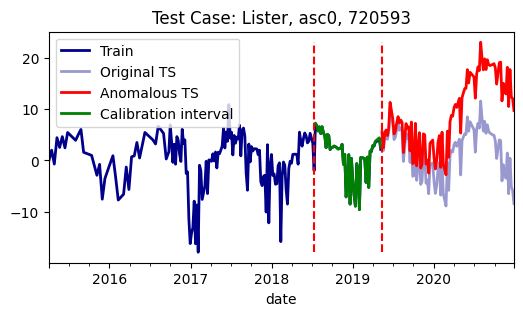

In [5]:
# Build some test anomalies

test_case1 = add_trend_increase(
    data,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
    increase_start_index=240,
).interpolate()
display_anomaly(test_case1, data)

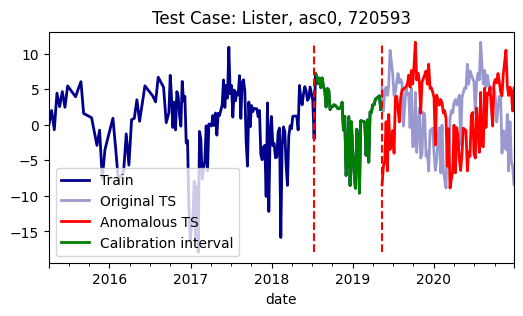

In [6]:
test_case2 = add_event_group(
    increase_start_index=250,
    df=data,
    event=reverse_event(data, increase_start_index=250, length=500),
).interpolate()
display_anomaly(test_case2, data)

# Model comparison for anomaly detection

Here we simply compare residual patterns of a naive model with a more sophisticated model

/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:169: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(sinfunc, tt, yy, p0=guess)
/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog=temporary.fillna(method="backfill"),
/home/gideon/miniconda3/envs/ki4ki/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog=temporary.fillna(method="backfill"),


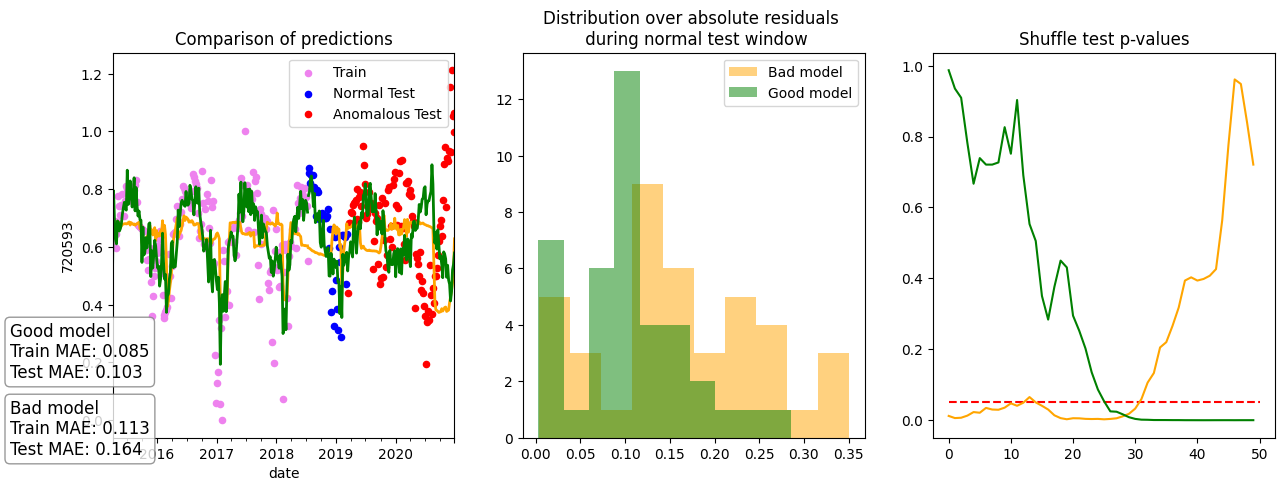

In [7]:
test_case = add_seasonal_cycle_increase(
    data,
    increase_start_index=250,
    increase_strength=0.2,
).interpolate()
train = test_case[:200]
test = test_case[200:]


# Naive model
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

resids = model(
    train,
    test,
    exogs,
    ax,
    past_days=0,
    autoregressive=0,
    naming="Bad model",
    text_pos=0.1,
    color="orange",
)

resids2 = model(
    train,
    test,
    exogs,
    ax,
    past_days=3,
    autoregressive=0,
    plot_bases=False,
    naming="Good model",
    cols=["W", "T"],
    color="green",
    text_pos=0.3,
)

ax[1].legend()


ax[0].set_title("Comparison of predictions", fontsize=12)
plt.show()

/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog=temporary.fillna(method="backfill"),
/home/gideon/miniconda3/envs/ki4ki/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog=temporary.fillna(method="backfill"),


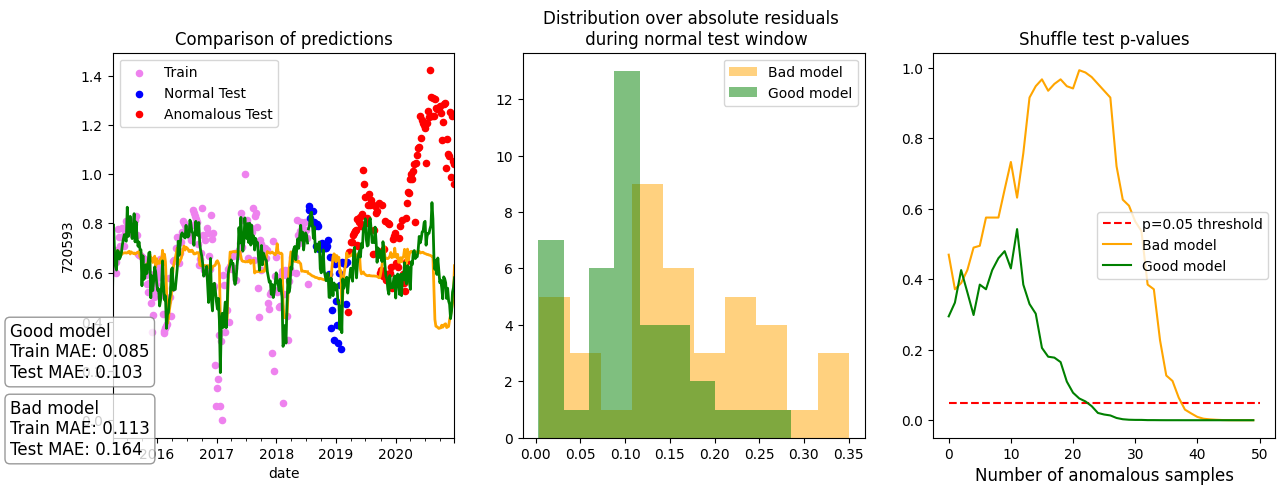

In [8]:
test_case = add_trend_increase(
    data,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
    increase_start_index=240,
).interpolate()


train = test_case[:200]
test = test_case[200:]


# Naive model
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

resids = model(
    train,
    test,
    exogs,
    ax,
    past_days=0,
    autoregressive=0,
    naming="Bad model",
    cols=["W"],
    text_pos=0.1,
    color="orange",
)

resids2 = model(
    train,
    test,
    exogs,
    ax,
    past_days=3,
    autoregressive=0,
    plot_bases=False,
    naming="Good model",
    cols=["W", "T"],
    color="green",
    text_pos=0.3,
)

# ax[0].legend()
# ax[0].legend(loc=3)
ax[1].legend()
ax[2].legend()

ax[2].set_xlabel("Number of anomalous samples", fontsize=12)

ax[0].set_title("Comparison of predictions", fontsize=12)

plt.savefig("../imgs/anomaly_baseline.png", dpi=200, bbox_inches="tight")

/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog=temporary.fillna(method="backfill"),
/home/gideon/miniconda3/envs/ki4ki/lib/python3.13/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
/home/gideon/project_repos/KI4KI/anomalies/synthetic_anomalies.py:87: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog=temporary.fillna(method="backfill"),


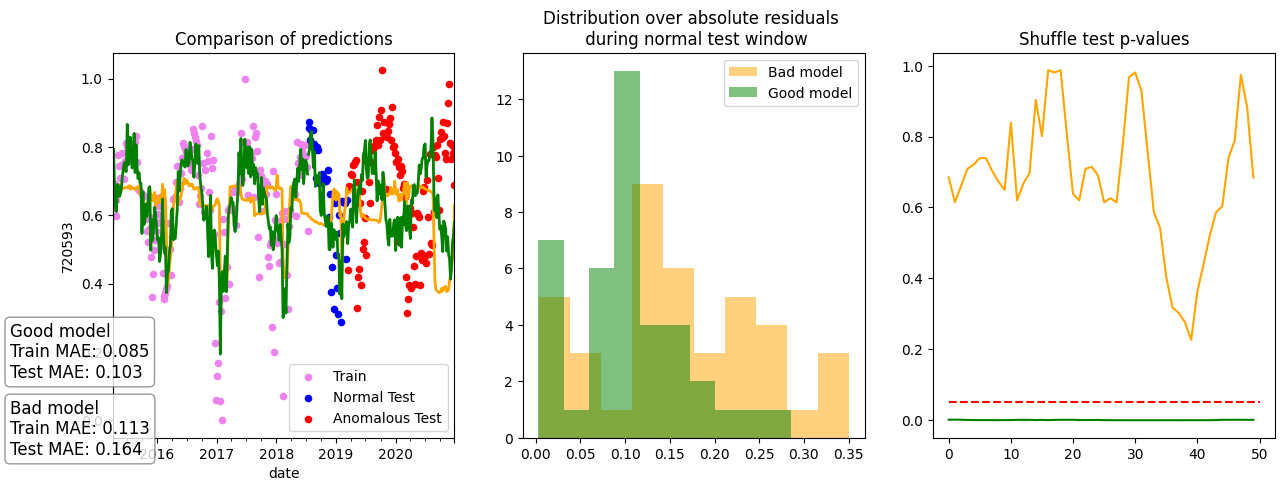

In [9]:
test_case1 = add_event_group(
    increase_start_index=250,
    df=data,
    event=reverse_event(data, increase_start_index=250, length=500),
).interpolate()
train = test_case1[:200]
test = test_case1[200:]


# Naive model
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

resids = model(
    train,
    test,
    exogs,
    ax,
    past_days=0,
    autoregressive=0,
    naming="Bad model",
    text_pos=0.1,
    color="orange",
)

resids2 = model(
    train,
    test,
    exogs,
    ax,
    past_days=3,
    autoregressive=0,
    plot_bases=False,
    naming="Good model",
    cols=["W", "T"],
    color="green",
    text_pos=0.3,
)

# ax[0].legend()
# ax[0].legend(loc=3)
ax[1].legend()


ax[0].set_title("Comparison of predictions", fontsize=12)
plt.show()